In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian import (
    run_to_end_vmapped, 
    square_input_wave,
    InterpolatedSample2D,
    KrivanekLens, 
    Biprism,
    sample_input_wave,
) 
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import energy2wavelength
from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.plotting import plot_model, PlotParams
from temgym_core.utils import make_tilted_uniform_cube, project_phase_along_z, interaction_constant_CE, e_over_hbar

from libertem_holo.base.reconstr import reconstruct_frame, phase_unwrap
from libertem_holo.base.utils import HoloParams
from libertem_holo.base.align import get_slice_fft
from libertem_holo.base.utils import remove_phase_ramp, estimate_sideband_position
from libertem_holo.base.filters import clipped

import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

In [2]:
import jax.numpy as jnp

def smoothstep01(t):
    """C^1 smoothstep from 0→1 on [0,1]."""
    t = jnp.clip(t, 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)

def projected_magnetic_cube_phase(
    tilt_x,
    N=256,
    L=250e-9,
    cube_fraction=0.5,  # full cube side / L
    x0=0.0,
    y0=0.0,
    V0=0.1,
    B0=0.8,
    voltage_eV=200e3,
    edge_fraction=0.15,  # fraction of half-side for taper region
):
    """
    Analytic electrostatic and magnetic phase maps for a uniform cube of side
    cube_fraction * L, tilted by tilt_x about x, with a parallel beam along +z_lab.

    Gauge: A_obj = (0, 0, B0 * X_obj).

    A 2D taper is applied to the *projection* so that near the projected cube
    boundary the phase is smoothly reduced to zero over a distance
    edge_fraction * a inside the edge.
    """

    # coordinates
    x = jnp.linspace(-L/2, L/2, N)
    y = jnp.linspace(-L/2, L/2, N)
    X, Y = jnp.meshgrid(x, y, indexing="ij")

    a = 0.5 * cube_fraction * L      # half-side of cube
    th = tilt_x
    s = jnp.sin(th)
    c = jnp.cos(th)

    # starting point of rays in object frame at z_lab = 0
    Y0 = Y * c
    Z0 = Y * s

    # condition for intersection in x
    inside_x = jnp.abs(X) <= a

    # slab intersections in t (distance along beam)
    # Y(t) = Y0 - t*s, |Y(t)| <= a
    tY_min = (Y0 - a) / s
    tY_max = (Y0 + a) / s

    # Z(t) = Z0 + t*c, |Z(t)| <= a
    tZ_min = (-a - Z0) / c
    tZ_max = ( a - Z0) / c

    t_in  = jnp.maximum(tY_min, tZ_min)
    t_out = jnp.minimum(tY_max, tZ_max)

    T = jnp.maximum(0.0, t_out - t_in)  # thickness along the beam
    T = jnp.where(inside_x, T, 0.0)

    # ------------- 2D edge taper on the projection -------------
    # Use object-frame transverse coords (X_obj = X, Y_obj = Y0)
    max_trans = jnp.maximum(jnp.abs(X), jnp.abs(Y0))
    signed_d = a - max_trans                 # >0 inside, 0 at edge
    w = edge_fraction * a                    # physical taper width

    # distance from edge, normalised to [0,1] over the inner taper region
    t_norm = jnp.clip(signed_d / jnp.maximum(w, 1e-20), 0.0, 1.0)
    # 0 at edge, 1 at inner end of taper → smoothstep→ multiply T
    taper_2d = smoothstep01(t_norm)

    # apply taper to thickness
    T_tapered = T * taper_2d

    C_E = interaction_constant_CE(voltage_eV)  # m^-1 V^-1
    C_B = e_over_hbar()              # m^-1 T

    # electrostatic phase   
    phi_el = C_E * V0 * T_tapered

    # A_z_lab = B0 * cos(theta) * X (X_obj = X_lab for an x-tilt)
    phi_mag = C_B * B0 * c * X * T_tapered

    field = jnp.exp(1j * (phi_el + phi_mag))

    x = x + x0
    y = y + y0

    return field, x, y

In [3]:
def make_sample_interpolant(input_cube_xy, input_cube_side_length, input_cube_x_tilt, voltage_eV):
    k = 2 * np.pi / energy2wavelength(voltage_eV)
    simulation_side_length = input_cube_side_length * 2
    cube_fraction = input_cube_side_length / simulation_side_length
    sample_fields, sample_x_coords, sample_y_coords, sample_z_coords = make_tilted_uniform_cube(
        tilt_x=input_cube_x_tilt,
        L=simulation_side_length,
        cube_fraction=cube_fraction,
        x0=input_cube_xy[0],
        y0=input_cube_xy[1],
        B0=0.4,
        V0=0.01,
        amplitude_dampening=1,
    )
    sample_amp, sample_phase_shift = project_phase_along_z(
        fields=sample_fields,
        z_coords=sample_z_coords,
        voltage=voltage_eV,
    )
    sample_field = sample_amp * np.exp(1j * sample_phase_shift / k)

    sample_interpolator = InterpolatedSample2D.from_array(sample=sample_field, x_coords=sample_x_coords, y_coords=sample_y_coords, z=0.0, method='cubic').interpolator

    return sample_interpolator, sample_x_coords, sample_y_coords, sample_field

In [4]:
def run_model(input_window_width_m=1e-6,
              fringe_spacing=6e-9, # Desired fringe spacing in metres
              num_pixels=256, # Number of pixels in detector
              voltage_eV=200e3,
              input_cube_xy=(0.0, 0.0),
              input_cube_x_tilt=0.0,  # radians
              input_cube_side_length=50e-9,  # metres
              obj_focal_length=2.5e-3,  # 2.5 mm
              obj_magnification=-1, # Must be negative
              defocus=0.0,
              beam_waist=2e-9,
              overlap_factor=2.0,
              detector_rotation=0.0):

    # Create input field
    wavelength = energy2wavelength(voltage_eV)
    k = 2 * np.pi / wavelength
    pixel_size = input_window_width_m / num_pixels

    sample_interpolator, sample_x_coords, sample_y_coords, sample_field = make_sample_interpolant(
        input_cube_xy=input_cube_xy,
        input_cube_side_length=input_cube_side_length,
        input_cube_x_tilt=input_cube_x_tilt,
        voltage_eV=voltage_eV,
    )

    rays_in = sample_input_wave(voltage=voltage_eV,
                                aperture_length=input_window_width_m * 1.0,
                                waist=beam_waist,
                                overlap_factor=overlap_factor,
                                z0=defocus,
                                sample_interpolator=sample_interpolator)
    

    input_grid = Detector(
    z=0.0,
    pixel_size=(pixel_size, pixel_size),
    shape=(num_pixels, num_pixels),
    )

    input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_in, input_grid).block_until_ready()

    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(np.abs(input_field), extent=input_grid.extent, cmap='inferno')
    axs[0].set_title('Input Field Amplitude')
    axs[1].imshow(np.angle(input_field), extent=input_grid.extent, cmap='twilight')
    axs[1].set_title('Input Field Phase')
    plt.tight_layout()

    # Set up Optical System - z1 = object plane distance from objective lens to sample - it's negative since the sample is before the lens
    # z2 = distance from objective lens to it's image plane
    z1, z2 = calculate_z1_and_z2_from_M_and_f(
        M=obj_magnification,
        f=obj_focal_length,
    )
    z1, z2 = map(abs, (z1, z2))  # Make distances positive

    # Calculate biprism strength needed for desired fringe spacing
    # Biprism is placed halfway between the objective lens focal plane (where the source is)
    # and it's image plane, where the friges will be observed.
    biprism_z = z1 + obj_focal_length + ((z1 + z2) - (z1 + obj_focal_length)) / 2 
    a = biprism_z - (z1 + obj_focal_length)
    b = ((z1 + z2) - biprism_z)

    # Quick assert to check distances add up
    L = a + b
    assert L == z1 + z2 - (z1 + obj_focal_length)

    b_def = wavelength * (a + b) / (2 * fringe_spacing * a)

    aberration_coefficients = KrivanekCoeffs(
        phi12=0.0,  # 45 degrees
    )
    objective_lens = KrivanekLens(z=z1, focal_length=obj_focal_length, coeffs=aberration_coefficients)
    biprism = Biprism(z=biprism_z, strength=b_def, width=1e-15)

    detector = Detector(
        z=z1 + z2,
        pixel_size=(pixel_size / 2.5, pixel_size / 2.5),
        shape=(num_pixels, num_pixels),
        rotation=detector_rotation
    )
    extent = detector.extent
    det_xy_coords_1d = detector.coords_1d

    rays_out_with_sample = run_to_end_vmapped(rays_in, (objective_lens, biprism, detector))
    output_holo_with_sample = evaluate_gaussians_gpu_kernel_wrapper(rays_out_with_sample, detector).block_until_ready()

    fig, axs = plt.subplots(1, 1)
    axs.imshow(np.abs(output_holo_with_sample), cmap='gray')
    axs.set_title('Hologram Intensity With Sample')
    axs.plot(rays_out_with_sample.x[::10000], rays_out_with_sample.y[::10000], 'r.', markersize=0.5)
    plt.tight_layout()

    return input_field, output_holo_with_sample, extent, det_xy_coords_1d, sample_field

/nobackup/dl277493/.pyenv/versions/JaxGym/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:5732: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  return array(a, dtype=dtype, copy=bool(copy), order=order, device=device)


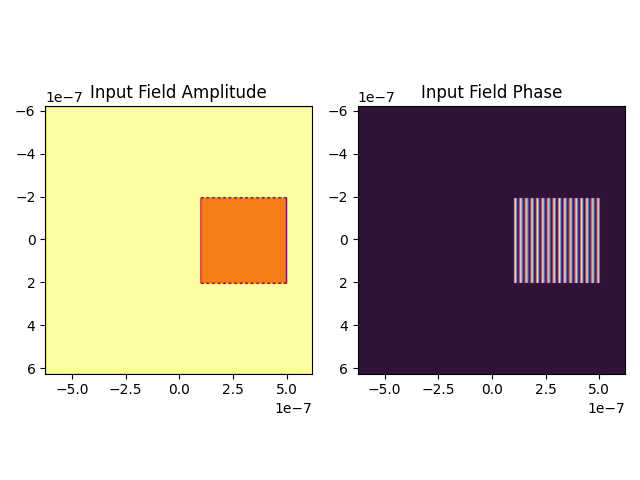

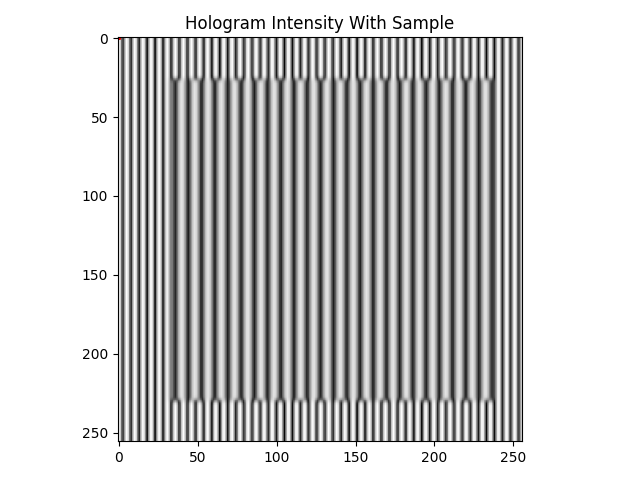

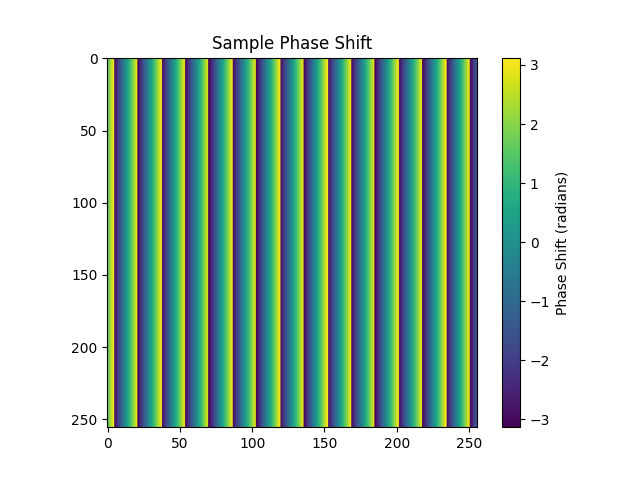

In [5]:
base_simulation_kwargs = dict(
    voltage_eV=200e3,
    input_window_width_m=1250e-9,
    fringe_spacing=10e-9,
    num_pixels=256,
    beam_waist=4e-9,
    input_cube_xy=(0.3e-6, 0.0e-6),
    input_cube_side_length=200e-9,
    input_cube_x_tilt=np.deg2rad(0),
    obj_magnification=-1,
    detector_rotation=0.0,
)

input_field_with_sample, output_holo_with_sample, extent, det_xy_coords_1d, sample_field = run_model(
    **base_simulation_kwargs
)

k=2 * np.pi / energy2wavelength(base_simulation_kwargs['voltage_eV'])
plt.figure()
plt.imshow(np.angle(np.exp(1j * np.angle(sample_field) * k)).T)
plt.title('Sample Phase Shift')
plt.colorbar(label='Phase Shift (radians)')

In [11]:
def reconstruct_wave_and_phase(hologram, roi=None, out_shape=None, xp=np):
    """Reconstruct the exit wave and unwrap the phase in a reusable helper."""
    if out_shape is None:
        out_shape = hologram.shape
    
    holo_params = HoloParams.from_hologram(
        hologram=hologram,
        out_shape=out_shape,
        xp=xp,
    )

    sb_pos = 255, 30
    slice_fft = get_slice_fft(sig_shape=hologram.shape, out_shape=out_shape)
    wave_obj = reconstruct_frame(
        frame=hologram,
        sb_pos=sb_pos,
        slice_fft=slice_fft,
        aperture=holo_params.aperture,
        xp=xp,
    )

    phase, _, _ = remove_phase_ramp(phase_unwrap(np.angle(wave_obj)), roi=roi)
    return wave_obj, phase, holo_params


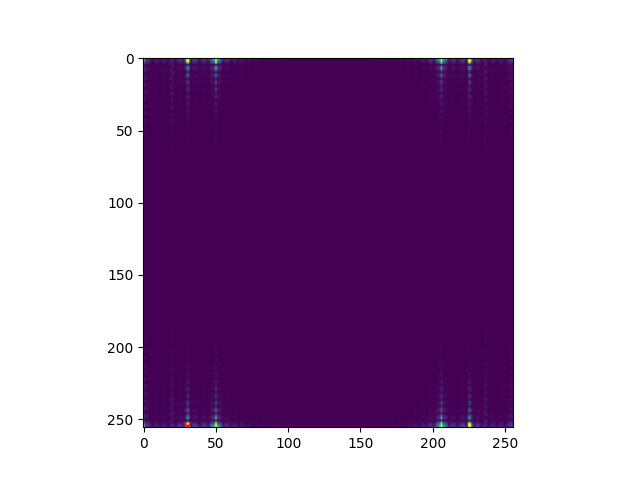

In [12]:
holo = np.abs(output_holo_with_sample) ** 2

wave_obj, phase, holo_params = reconstruct_wave_and_phase(
    hologram=holo, roi=np.s_[1:12, 0:200]
)

fft = np.fft.fft2(holo)
img = np.abs(fft)

sb_pos = holo_params.sb_position

plt.figure()
plt.imshow(img, vmin=np.min(clipped(img)), vmax=np.max(clipped(img)))
plt.plot(30, 255, 'rx')

phase_wrapped = np.angle(np.exp(1j * phase))
phase_wrapped_zeroed = phase_wrapped - np.mean(phase_wrapped)

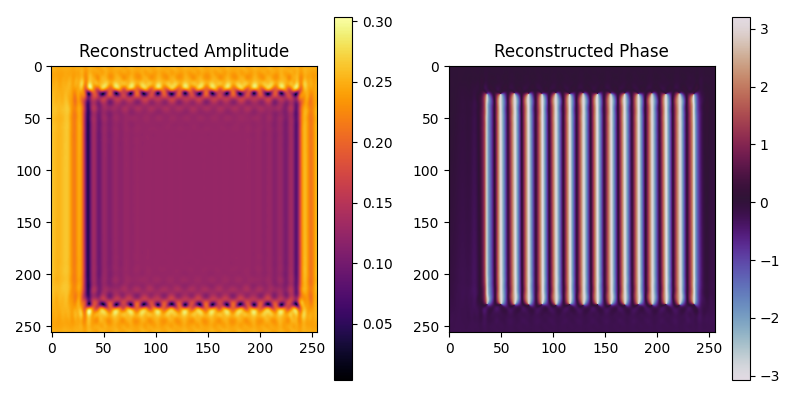

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
im0 = axs[0].imshow(np.abs(wave_obj), cmap='inferno')
axs[0].set_title('Reconstructed Amplitude')
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(phase_wrapped_zeroed, cmap='twilight')
axs[1].set_title('Reconstructed Phase')
fig.colorbar(im1, ax=axs[1])
plt.tight_layout()